## 03 Procesamiento de Data

1. Revisión de datos (primeros 5 y ultimos 5)
2. Eliminamos las columnas irrelevantes para el análisis.
3. Ingeniería de atributos (Pandemia)
4. Eliminación de meses de "Pandemia"
5. Separacion de variables categoricas y numericas
6. Variables numéricas
   1. Convertimos a log1p las variables con asimetría positiva.
   2. Identificación de Outliers (IQR). 
   3. Imputación de Nulos mediante Random forest regresor
   4. Medimos la correlación de varibales numéricas
   5. Devolvemos las variables a su valor original.
7. Juntamos las variables numéricas imputadas con las vairables Categóricas
8. Guardado de datos preprocesados.

In [63]:
import pandas as pd

# Configuraciones del notebbok
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)

data_base = pd.read_csv('../Data/Row/Flujo vehicular registrado en peajes_2014-2025_II.csv', encoding='latin-1')
data_pbi = pd.read_excel('../Data/Row/PBI_Mensual_201401_202508.xlsx', sheet_name='Mensuales')
data_feriados = pd.read_csv('../Data/Row/Feriados_No_Laborables_Fines_de_semana.csv')

# Tratamos el dataset PBI
data_pbi['Mes'].unique()

dic_mes = {'Ene':1, 'Feb':2, 'Mar':3, 'Abr':4, 'May':5, 'Jun':6, 'Jul':7, 'Ago':8, 'Sep':9, 'Oct':10, 'Nov':11, 'Dic':12}
dic_anio = {'14':'2014', '15':'2015', '16':'2016', '17':'2017', '18':'2018', '19':'2019', '20':'2020', '21':'2021', '22':'2022', '23':'2023', '24':'2024', '25':'2025'}
data_pbi['Mes_str'] = data_pbi['Mes'].apply(lambda x: dic_mes[x[:3]])
data_pbi['Anio_str'] = data_pbi['Mes'].apply(lambda x: dic_anio[x[3:]])

# Creamos las llaves
data_base['llave'] = data_base['ANIO'].astype(str) + data_base['MES'].astype(str)
data_pbi['llave'] = data_pbi['Anio_str'].astype(str) + data_pbi['Mes_str'].astype(str)
data_feriados['llave'] = data_feriados['Anio'].astype(str) + data_feriados['Mes'].astype(str)

# juntamos la información
data_merge_01 = data_base.merge(data_pbi, on='llave', how='left')
data_total = data_merge_01.merge(data_feriados, on='llave', how='left')

# Eliminamos columnas no significativas o innecesarias del merge
data_total_f = data_total.drop(columns=['Mes_str', 'Anio_str', 'Mes_y', 'ID', 'Mes_x', 'Anio', 'NOMBRE_PEAJE'])

In [64]:
data_total_f.columns

Index(['ADMINIST', 'CODIGO_PEAJE', 'DEPARTAMENTO', 'VEH_LIGEROS_TAR_DIF',
       'VEH_LIGEROS_AUTOMOVILES', 'VEH_PESADOS_TAR_DIF', 'VEH_PESADOS__2E',
       'VEH_PESADOS_3E', 'VEH_PESADOS_4E', 'VEH_PESADOS_5E', 'VEH_PESADOS_6E',
       'VEH_PESADOS_7E', 'VEH_LIGEROS_TOTAL', 'VEH_LIGEROS_IMD',
       'VEH_PESADOS_TOTAL', 'VEH_PESADOS_IMD', 'VEH_TOTAL', 'VEH_IMD', 'ANIO',
       'MES', 'PERIODO', 'llave', 'PBI', 'Feriados',
       'No_Laborables_Fuera_de_Feriado', 'Fines_de_Semana'],
      dtype='object')

In [65]:
# Eliminamos las oclumnas que no nos sirven
df_prep = data_total_f.copy()

df_prep.head(5)

,ADMINIST,CODIGO_PEAJE,DEPARTAMENTO,VEH_LIGEROS_TAR_DIF,VEH_LIGEROS_AUTOMOVILES,VEH_PESADOS_TAR_DIF,VEH_PESADOS__2E,VEH_PESADOS_3E,VEH_PESADOS_4E,VEH_PESADOS_5E,VEH_PESADOS_6E,VEH_PESADOS_7E,VEH_LIGEROS_TOTAL,VEH_LIGEROS_IMD,VEH_PESADOS_TOTAL,VEH_PESADOS_IMD,VEH_TOTAL,VEH_IMD,ANIO,MES,PERIODO,llave,PBI,Feriados,No_Laborables_Fuera_de_Feriado,Fines_de_Semana
0,Concesionado,22PE5NACS1,San Martín,2099,8070.0,0,2586.0,2374.0,720.0,315.0,3512.0,8.0,10169,328.0,9515,306.9,19684,635.0,2014,1,201401,20141,136.331425,1,1,8
1,Concesionado,04PE1SCAM1,Arequipa,0,24644.0,0,6502.0,4622.0,1654.0,3028.0,8711.0,213.0,24644,795.0,24730,797.7,49374,1592.7,2014,1,201401,20141,136.331425,1,1,8
2,Concesionado,21PE3SCRO1,Puno,33643,82139.0,5797,17981.0,5307.0,1150.0,1737.0,5342.0,12.0,115782,3734.9,37326,1204.1,153108,4939.0,2014,1,201401,20141,136.331425,1,1,8
3,Concesionado,12PE3NCRA1,Junín,10,46944.0,0,16981.0,18585.0,4463.0,3058.0,19400.0,135.0,46954,1514.6,62622,2020.1,109576,3534.7,2014,1,201401,20141,136.331425,1,1,8
4,Concesionado,08PE3SCSC1,Cusco,0,23831.0,0,4709.0,3941.0,447.0,769.0,3945.0,95.0,23831,768.7,13906,448.6,37737,1217.3,2014,1,201401,20141,136.331425,1,1,8


In [66]:
df_prep.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10781 entries, 0 to 10780
Data columns (total 26 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   ADMINIST                        10781 non-null  object 
 1   CODIGO_PEAJE                    10781 non-null  object 
 2   DEPARTAMENTO                    10781 non-null  object 
 3   VEH_LIGEROS_TAR_DIF             10781 non-null  int64  
 4   VEH_LIGEROS_AUTOMOVILES         10768 non-null  float64
 5   VEH_PESADOS_TAR_DIF             10781 non-null  int64  
 6   VEH_PESADOS__2E                 10773 non-null  float64
 7   VEH_PESADOS_3E                  10773 non-null  float64
 8   VEH_PESADOS_4E                  10773 non-null  float64
 9   VEH_PESADOS_5E                  10773 non-null  float64
 10  VEH_PESADOS_6E                  10773 non-null  float64
 11  VEH_PESADOS_7E                  10773 non-null  float64
 12  VEH_LIGEROS_TOTAL               

In [67]:
# Feature Enginnering
df_prep['Pandemia'] = df_prep['PERIODO'].apply(lambda x: 1 if str(x).startswith('2020') else 0 )

df_prep.head(5)

,ADMINIST,CODIGO_PEAJE,DEPARTAMENTO,VEH_LIGEROS_TAR_DIF,VEH_LIGEROS_AUTOMOVILES,VEH_PESADOS_TAR_DIF,VEH_PESADOS__2E,VEH_PESADOS_3E,VEH_PESADOS_4E,VEH_PESADOS_5E,VEH_PESADOS_6E,VEH_PESADOS_7E,VEH_LIGEROS_TOTAL,VEH_LIGEROS_IMD,VEH_PESADOS_TOTAL,VEH_PESADOS_IMD,VEH_TOTAL,VEH_IMD,ANIO,MES,PERIODO,llave,PBI,Feriados,No_Laborables_Fuera_de_Feriado,Fines_de_Semana,Pandemia
0,Concesionado,22PE5NACS1,San Martín,2099,8070.0,0,2586.0,2374.0,720.0,315.0,3512.0,8.0,10169,328.0,9515,306.9,19684,635.0,2014,1,201401,20141,136.331425,1,1,8,0
1,Concesionado,04PE1SCAM1,Arequipa,0,24644.0,0,6502.0,4622.0,1654.0,3028.0,8711.0,213.0,24644,795.0,24730,797.7,49374,1592.7,2014,1,201401,20141,136.331425,1,1,8,0
2,Concesionado,21PE3SCRO1,Puno,33643,82139.0,5797,17981.0,5307.0,1150.0,1737.0,5342.0,12.0,115782,3734.9,37326,1204.1,153108,4939.0,2014,1,201401,20141,136.331425,1,1,8,0
3,Concesionado,12PE3NCRA1,Junín,10,46944.0,0,16981.0,18585.0,4463.0,3058.0,19400.0,135.0,46954,1514.6,62622,2020.1,109576,3534.7,2014,1,201401,20141,136.331425,1,1,8,0
4,Concesionado,08PE3SCSC1,Cusco,0,23831.0,0,4709.0,3941.0,447.0,769.0,3945.0,95.0,23831,768.7,13906,448.6,37737,1217.3,2014,1,201401,20141,136.331425,1,1,8,0


In [68]:
# Eliminamos del analisis el tiempo de periodo de la pandemia - (No considerar todo el año - Evaluar)
df_filter = df_prep[df_prep['Pandemia'] != 1]

In [69]:
# Separacion de variables por numericas y categoricas

df_prep_num = df_filter.select_dtypes(include=['int64', 'float64','number'])
df_prep_cat = df_filter.select_dtypes(include=['object', 'category'])

### Trabajamos las variables numéricas

In [70]:
df_prep_num.head()

,VEH_LIGEROS_TAR_DIF,VEH_LIGEROS_AUTOMOVILES,VEH_PESADOS_TAR_DIF,VEH_PESADOS__2E,VEH_PESADOS_3E,VEH_PESADOS_4E,VEH_PESADOS_5E,VEH_PESADOS_6E,VEH_PESADOS_7E,VEH_LIGEROS_TOTAL,VEH_LIGEROS_IMD,VEH_PESADOS_TOTAL,VEH_PESADOS_IMD,VEH_TOTAL,VEH_IMD,ANIO,MES,PERIODO,PBI,Feriados,No_Laborables_Fuera_de_Feriado,Fines_de_Semana,Pandemia
0,2099,8070.0,0,2586.0,2374.0,720.0,315.0,3512.0,8.0,10169,328.0,9515,306.9,19684,635.0,2014,1,201401,136.331425,1,1,8,0
1,0,24644.0,0,6502.0,4622.0,1654.0,3028.0,8711.0,213.0,24644,795.0,24730,797.7,49374,1592.7,2014,1,201401,136.331425,1,1,8,0
2,33643,82139.0,5797,17981.0,5307.0,1150.0,1737.0,5342.0,12.0,115782,3734.9,37326,1204.1,153108,4939.0,2014,1,201401,136.331425,1,1,8,0
3,10,46944.0,0,16981.0,18585.0,4463.0,3058.0,19400.0,135.0,46954,1514.6,62622,2020.1,109576,3534.7,2014,1,201401,136.331425,1,1,8,0
4,0,23831.0,0,4709.0,3941.0,447.0,769.0,3945.0,95.0,23831,768.7,13906,448.6,37737,1217.3,2014,1,201401,136.331425,1,1,8,0


C:\Users\lenovo\AppData\Local\Temp\ipykernel_19920\887561714.py:14: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(df_prep_num[atribute], fill=True)


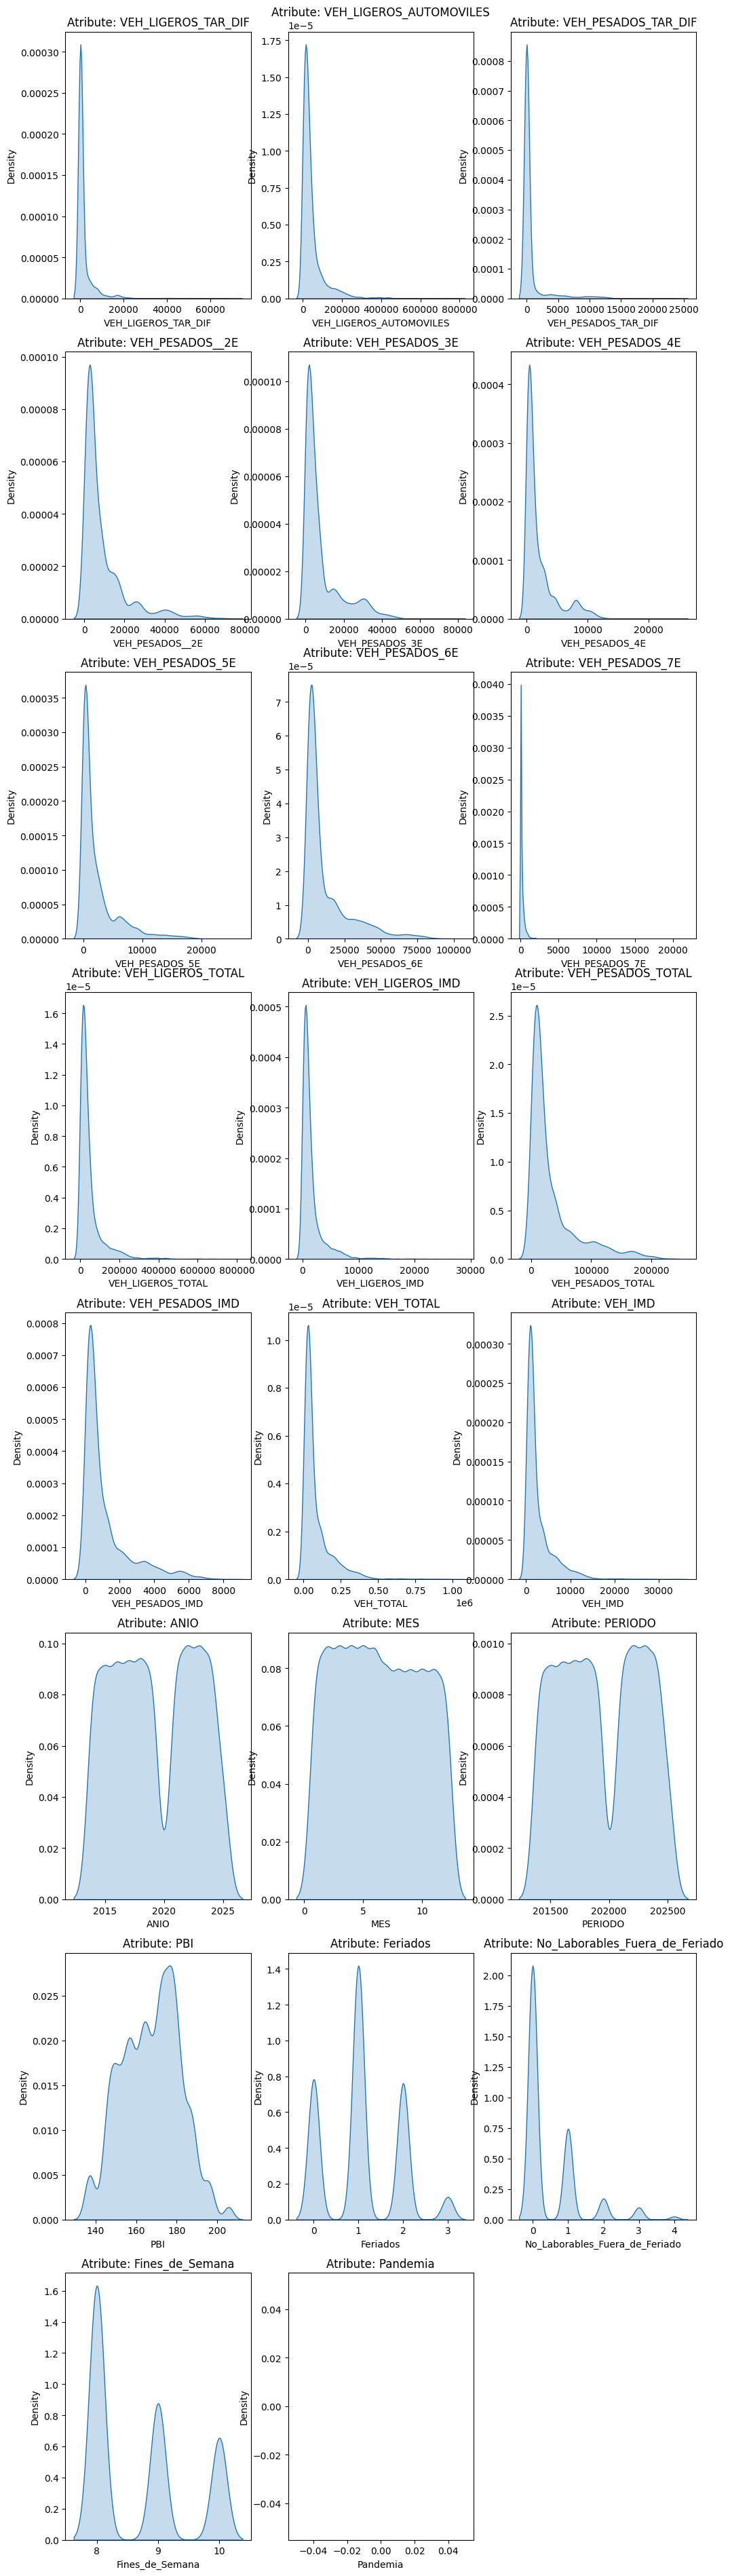

In [71]:
import math
import matplotlib.pyplot as plt
import seaborn as sns

n_cols = 3

n_vars = len(df_prep_num.columns)
n_rows = math.ceil(n_vars / n_cols)

plt.figure(figsize=(12, n_rows*6))

for i, atribute in enumerate(df_prep_num.columns):
    plt.subplot(n_rows, n_cols, i+1)
    sns.kdeplot(df_prep_num[atribute], fill=True)

    plt.title(f'Atribute: {atribute}')

In [72]:
df_prep_num.columns

Index(['VEH_LIGEROS_TAR_DIF', 'VEH_LIGEROS_AUTOMOVILES', 'VEH_PESADOS_TAR_DIF',
       'VEH_PESADOS__2E', 'VEH_PESADOS_3E', 'VEH_PESADOS_4E', 'VEH_PESADOS_5E',
       'VEH_PESADOS_6E', 'VEH_PESADOS_7E', 'VEH_LIGEROS_TOTAL',
       'VEH_LIGEROS_IMD', 'VEH_PESADOS_TOTAL', 'VEH_PESADOS_IMD', 'VEH_TOTAL',
       'VEH_IMD', 'ANIO', 'MES', 'PERIODO', 'PBI', 'Feriados',
       'No_Laborables_Fuera_de_Feriado', 'Fines_de_Semana', 'Pandemia'],
      dtype='object')

In [73]:
import numpy as np

columnas_a_normalizar = ['VEH_LIGEROS_TAR_DIF', 'VEH_LIGEROS_AUTOMOVILES', 'VEH_PESADOS_TAR_DIF',
       'VEH_PESADOS__2E', 'VEH_PESADOS_3E', 'VEH_PESADOS_4E', 'VEH_PESADOS_5E',
       'VEH_PESADOS_6E', 'VEH_PESADOS_7E']

df_prep_num_log = df_prep_num.copy()

for col in columnas_a_normalizar:
    df_prep_num_log[col] = df_prep_num[col].apply(np.log1p)

C:\Users\lenovo\AppData\Local\Temp\ipykernel_19920\4200661542.py:12: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(df_prep_num_log[atribute], fill=True)


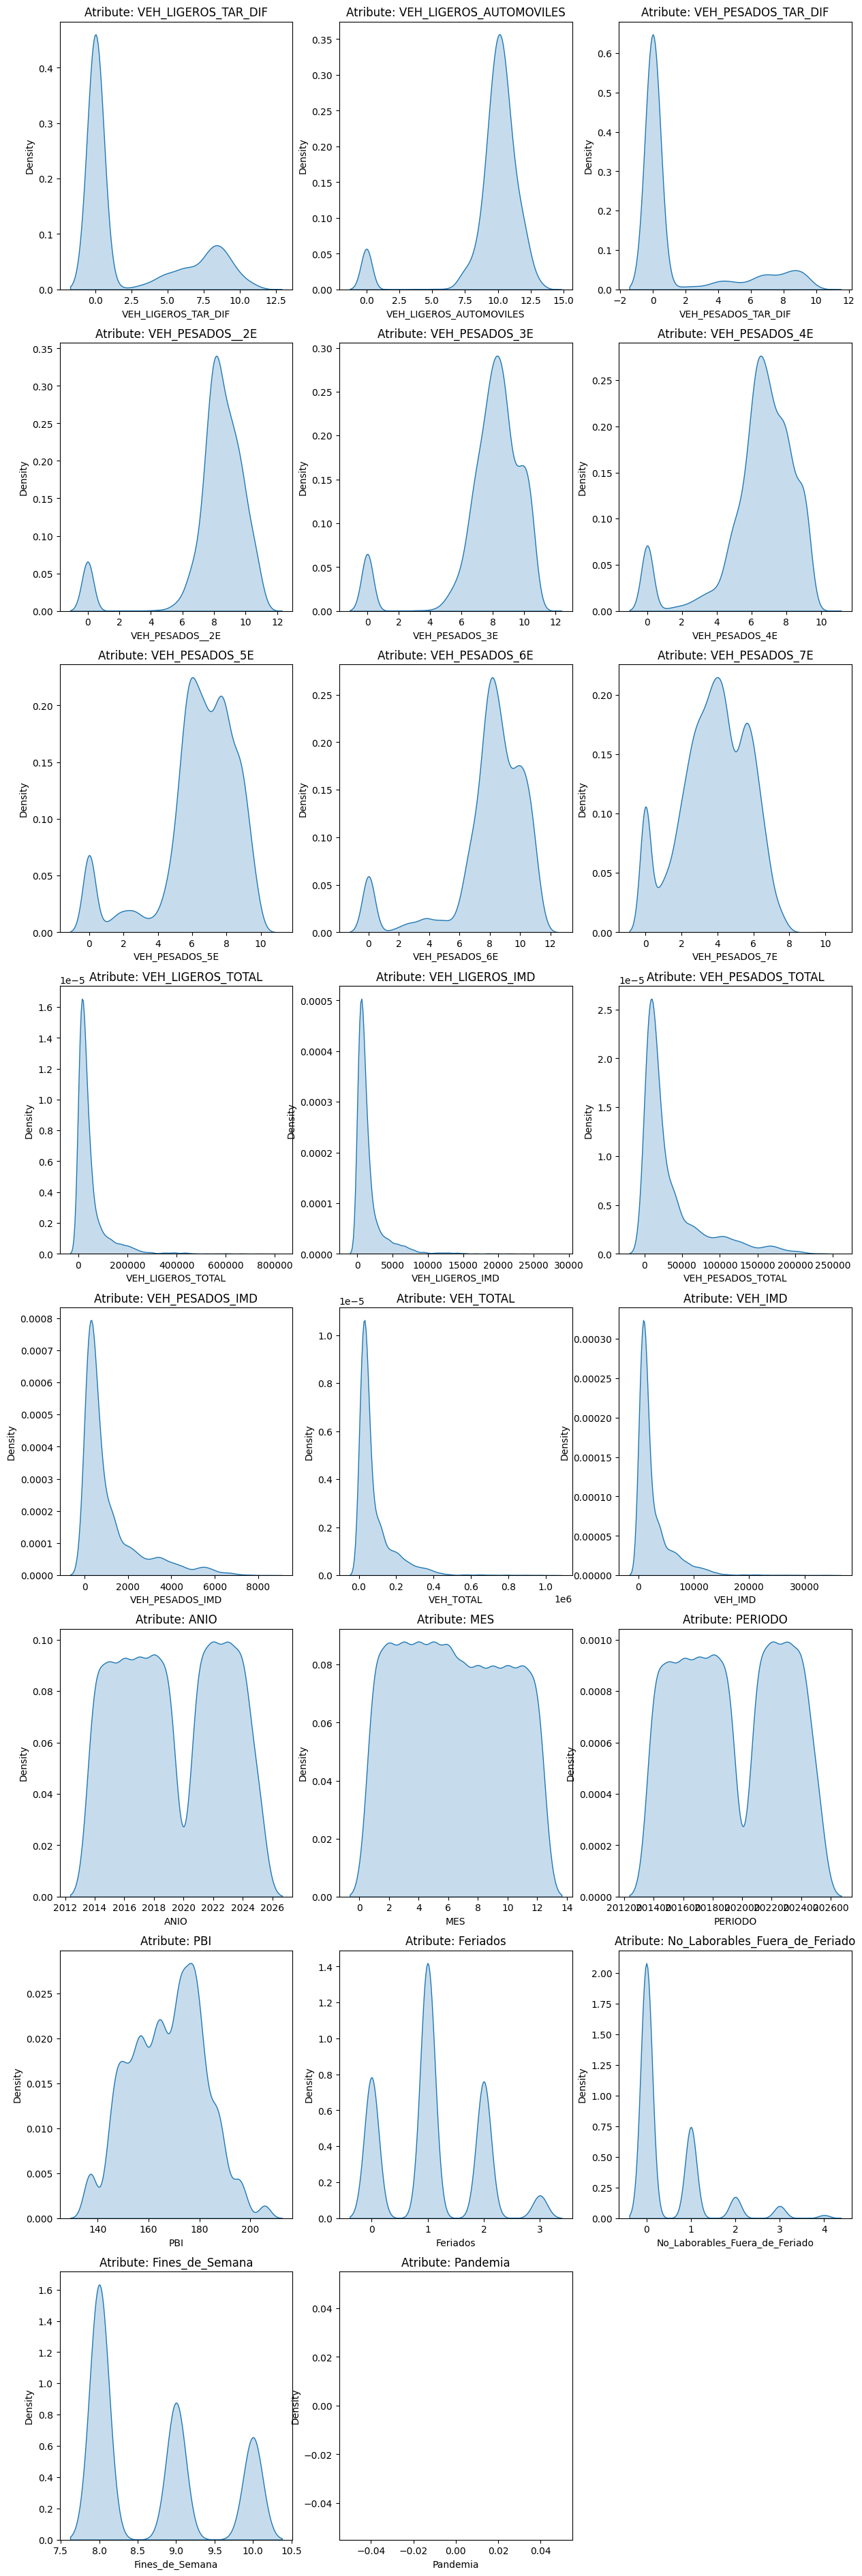

In [74]:
#Graficamos para verificar el cambio

n_cols = 3

n_vars = len(df_prep_num_log.columns)
n_rows = math.ceil( n_vars / n_cols)

plt.figure(figsize=(15, n_rows*6))

for i, atribute in enumerate(df_prep_num_log.columns):
    plt.subplot(n_rows, n_cols, i + 1)
    sns.kdeplot(df_prep_num_log[atribute], fill=True)
    plt.title(f'Atribute: {atribute}')

In [75]:
# Identificación de outliers de las variables numéricas
def iqr_filter(df_prep_num_log):
    Q1 = df_prep_num_log.quantile(0.25)
    Q3 = df_prep_num_log.quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5*IQR
    upper_bound = Q3 + 1.5*IQR

    df_prep_filtered_num = df_prep_num_log[(df_prep_num_log >= lower_bound) & (df_prep_num_log <= upper_bound)]
    return df_prep_filtered_num

# Realizamos la imputaciones de los outliers extraidos
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.ensemble import RandomForestRegressor

def rf_imputer(df_prep_filtered_num):

    rf_optimizado = RandomForestRegressor(
        n_jobs=-1,        
        n_estimators=10,  
        max_depth=10,     
        random_state=42  
    )

    imputer_num = IterativeImputer(estimator=rf_optimizado, max_iter=5, verbose=2)

    df_num_imputed = imputer_num.fit_transform(df_prep_filtered_num)
    df_num_imputed = pd.DataFrame(df_num_imputed, columns=df_prep_filtered_num.columns)

    return df_num_imputed


In [76]:
df_num_log_peaje = pd.concat([df_prep_num_log, df_prep_cat['CODIGO_PEAJE']], axis=1)

list_df_imputed = list()

for pea in df_num_log_peaje['CODIGO_PEAJE'].unique():
    df_temp = df_num_log_peaje[df_num_log_peaje['CODIGO_PEAJE'] == pea].drop(columns='CODIGO_PEAJE')
    #print(df_temp.info())

    df_temp_iqr = iqr_filter(df_temp)
    #print(df_temp_iqr.info())

    df_temp_imputed = rf_imputer(df_temp_iqr)
    #print(df_temp_imputed.info())

    df_temp_imputed['CODIGO_PEAJE'] = pea

    list_df_imputed.append(df_temp_imputed)

    
df_total_imputed = pd.concat(list_df_imputed, ignore_index=True)

[IterativeImputer] Completing matrix with shape (126, 23)
[IterativeImputer] Ending imputation round 1/5, elapsed time 0.67
[IterativeImputer] Change: 1646.0264111238255, scaled tolerance: 202.506 
[IterativeImputer] Ending imputation round 2/5, elapsed time 1.33
[IterativeImputer] Change: 144.12, scaled tolerance: 202.506 
[IterativeImputer] Early stopping criterion reached.
[IterativeImputer] Completing matrix with shape (126, 23)
[IterativeImputer] Ending imputation round 1/5, elapsed time 0.57
[IterativeImputer] Change: 59487.72716552088, scaled tolerance: 202.506 
[IterativeImputer] Ending imputation round 2/5, elapsed time 1.14
[IterativeImputer] Change: 0.00784146110236339, scaled tolerance: 202.506 
[IterativeImputer] Early stopping criterion reached.
[IterativeImputer] Completing matrix with shape (117, 23)
[IterativeImputer] Ending imputation round 1/5, elapsed time 0.69
[IterativeImputer] Change: 8343.140910228702, scaled tolerance: 291.795 
[IterativeImputer] Ending imputat

c:\Users\lenovo\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\impute\_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


[IterativeImputer] Ending imputation round 1/5, elapsed time 0.67
[IterativeImputer] Change: 15603.698064516124, scaled tolerance: 202.506 
[IterativeImputer] Ending imputation round 2/5, elapsed time 1.32
[IterativeImputer] Change: 5446.410000000009, scaled tolerance: 202.506 
[IterativeImputer] Ending imputation round 3/5, elapsed time 2.00
[IterativeImputer] Change: 1253.0900000000204, scaled tolerance: 202.506 
[IterativeImputer] Ending imputation round 4/5, elapsed time 2.67
[IterativeImputer] Change: 213.6800000000003, scaled tolerance: 202.506 
[IterativeImputer] Ending imputation round 5/5, elapsed time 3.33
[IterativeImputer] Change: 1.7763568394002505e-15, scaled tolerance: 202.506 
[IterativeImputer] Early stopping criterion reached.
[IterativeImputer] Completing matrix with shape (117, 23)
[IterativeImputer] Ending imputation round 1/5, elapsed time 0.65
[IterativeImputer] Change: 2831.0198773955135, scaled tolerance: 202.41 
[IterativeImputer] Ending imputation round 2/5, 

c:\Users\lenovo\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\impute\_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


[IterativeImputer] Ending imputation round 1/5, elapsed time 0.63
[IterativeImputer] Change: 5.541883670842829, scaled tolerance: 408.377 
[IterativeImputer] Early stopping criterion reached.
[IterativeImputer] Completing matrix with shape (126, 23)
[IterativeImputer] Ending imputation round 1/5, elapsed time 0.55
[IterativeImputer] Change: 1.2363636363636363, scaled tolerance: 1037.544 
[IterativeImputer] Early stopping criterion reached.
[IterativeImputer] Completing matrix with shape (126, 23)
[IterativeImputer] Ending imputation round 1/5, elapsed time 0.68
[IterativeImputer] Change: 8537.341342648167, scaled tolerance: 202.506 
[IterativeImputer] Ending imputation round 2/5, elapsed time 1.35
[IterativeImputer] Change: 4216.444013760279, scaled tolerance: 202.506 
[IterativeImputer] Ending imputation round 3/5, elapsed time 2.03
[IterativeImputer] Change: 10818.31367151272, scaled tolerance: 202.506 
[IterativeImputer] Ending imputation round 4/5, elapsed time 2.70
[IterativeImput

...

[IterativeImputer] Ending imputation round 1/5, elapsed time 0.55
[IterativeImputer] Change: 22.877547201582832, scaled tolerance: 202.506 
[IterativeImputer] Early stopping criterion reached.
[IterativeImputer] Completing matrix with shape (102, 23)
[IterativeImputer] Ending imputation round 1/5, elapsed time 0.69
[IterativeImputer] Change: 14640.882091348043, scaled tolerance: 202.506 
[IterativeImputer] Ending imputation round 2/5, elapsed time 1.39
[IterativeImputer] Change: 11951.709448638354, scaled tolerance: 202.506 
[IterativeImputer] Ending imputation round 3/5, elapsed time 2.07
[IterativeImputer] Change: 6214.797995618907, scaled tolerance: 202.506 
[IterativeImputer] Ending imputation round 4/5, elapsed time 2.75
[IterativeImputer] Change: 3699.676684725148, scaled tolerance: 202.506 
[IterativeImputer] Ending imputation round 5/5, elapsed time 3.43
[IterativeImputer] Change: 1324.7921824943019, scaled tolerance: 202.506 
[IterativeImputer] Completing matrix with shape (78

c:\Users\lenovo\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\impute\_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


[IterativeImputer] Ending imputation round 1/5, elapsed time 0.67
[IterativeImputer] Change: 449.7447497767603, scaled tolerance: 202.506 
[IterativeImputer] Ending imputation round 2/5, elapsed time 1.34
[IterativeImputer] Change: 124.3341640239737, scaled tolerance: 202.506 
[IterativeImputer] Early stopping criterion reached.
[IterativeImputer] Completing matrix with shape (66, 23)
[IterativeImputer] Ending imputation round 1/5, elapsed time 0.66
[IterativeImputer] Change: 1344.9553007749487, scaled tolerance: 202.506 
[IterativeImputer] Ending imputation round 2/5, elapsed time 1.31
[IterativeImputer] Change: 906.137111097504, scaled tolerance: 202.506 
[IterativeImputer] Ending imputation round 3/5, elapsed time 1.96
[IterativeImputer] Change: 53.205141713797836, scaled tolerance: 202.506 
[IterativeImputer] Early stopping criterion reached.
[IterativeImputer] Completing matrix with shape (56, 23)
[IterativeImputer] Ending imputation round 1/5, elapsed time 0.60
[IterativeImputer]

c:\Users\lenovo\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\impute\_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


[IterativeImputer] Ending imputation round 1/5, elapsed time 0.51
[IterativeImputer] Change: 1327.353333333333, scaled tolerance: 202.506 
[IterativeImputer] Ending imputation round 2/5, elapsed time 1.02
[IterativeImputer] Change: 0.0, scaled tolerance: 202.506 
[IterativeImputer] Early stopping criterion reached.


In [77]:
df_total_imputed.head()

,VEH_LIGEROS_TAR_DIF,VEH_LIGEROS_AUTOMOVILES,VEH_PESADOS_TAR_DIF,VEH_PESADOS__2E,VEH_PESADOS_3E,VEH_PESADOS_4E,VEH_PESADOS_5E,VEH_PESADOS_6E,VEH_PESADOS_7E,VEH_LIGEROS_TOTAL,VEH_LIGEROS_IMD,VEH_PESADOS_TOTAL,VEH_PESADOS_IMD,VEH_TOTAL,VEH_IMD,ANIO,MES,PERIODO,PBI,Feriados,No_Laborables_Fuera_de_Feriado,Fines_de_Semana,Pandemia,CODIGO_PEAJE
0,7.649693,8.996033,0.0,7.858254,7.772753,6.580639,5.755742,8.164226,2.197225,10169.0,328.0,9515.0,306.9,19684.0,635.0,2014.0,1.0,201401.0,136.331425,1.0,1.0,8.0,0.0,22PE5NACS1
1,7.579679,8.871505,0.0,7.792349,7.754482,6.493754,5.863631,8.159661,2.833213,9082.0,324.4,9275.0,331.2,18357.0,655.6,2014.0,2.0,201402.0,136.032830,0.0,0.0,8.0,0.0,22PE5NACS1
2,7.824446,8.830251,0.0,7.876259,7.798933,6.602588,5.953243,8.228444,3.135494,9337.0,301.2,9957.0,321.2,19294.0,622.4,2014.0,3.0,201403.0,144.308470,0.0,0.0,10.0,0.0,22PE5NACS1
3,7.852439,8.875007,0.0,7.840313,7.741968,6.447306,5.888878,8.247744,3.044522,9721.0,324.0,9670.0,322.3,19391.0,646.4,2014.0,4.0,201404.0,146.068668,2.0,0.0,8.0,0.0,22PE5NACS1
4,8.024207,8.932477,0.0,7.889459,7.808323,6.502790,6.001415,8.299535,3.583519,10626.0,342.8,10253.0,330.7,20879.0,673.5,2014.0,5.0,201405.0,148.341447,1.0,0.0,9.0,0.0,22PE5NACS1


<Axes: >

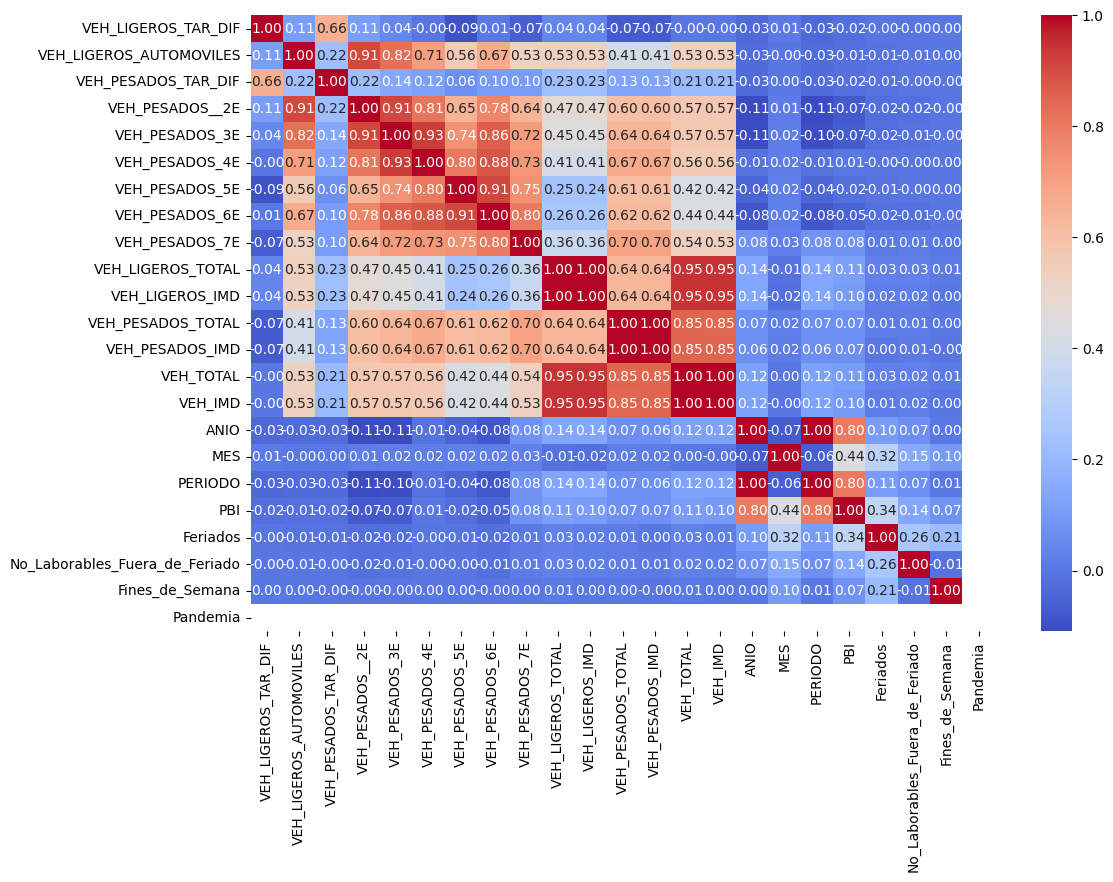

In [78]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

corr_matrix = df_total_imputed.drop(columns=['CODIGO_PEAJE']).corr()
mask = plt.figure(figsize=(12,8))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap='coolwarm',
    cbar=True
)


In [79]:
# Regresamos a su valor original las columnas transformadas a log1p

df_prep_num_desnorm = df_total_imputed.copy()

for col_2 in columnas_a_normalizar:
    df_prep_num_desnorm[col_2] = df_total_imputed[col_2].apply(np.expm1)

In [80]:
df_prep_num_desnorm.head()

,VEH_LIGEROS_TAR_DIF,VEH_LIGEROS_AUTOMOVILES,VEH_PESADOS_TAR_DIF,VEH_PESADOS__2E,VEH_PESADOS_3E,VEH_PESADOS_4E,VEH_PESADOS_5E,VEH_PESADOS_6E,VEH_PESADOS_7E,VEH_LIGEROS_TOTAL,VEH_LIGEROS_IMD,VEH_PESADOS_TOTAL,VEH_PESADOS_IMD,VEH_TOTAL,VEH_IMD,ANIO,MES,PERIODO,PBI,Feriados,No_Laborables_Fuera_de_Feriado,Fines_de_Semana,Pandemia,CODIGO_PEAJE
0,2099.0,8070.0,0.0,2586.0,2374.0,720.0,315.0,3512.0,8.0,10169.0,328.0,9515.0,306.9,19684.0,635.0,2014.0,1.0,201401.0,136.331425,1.0,1.0,8.0,0.0,22PE5NACS1
1,1957.0,7125.0,0.0,2421.0,2331.0,660.0,351.0,3496.0,16.0,9082.0,324.4,9275.0,331.2,18357.0,655.6,2014.0,2.0,201402.0,136.032830,0.0,0.0,8.0,0.0,22PE5NACS1
2,2500.0,6837.0,0.0,2633.0,2437.0,736.0,384.0,3745.0,22.0,9337.0,301.2,9957.0,321.2,19294.0,622.4,2014.0,3.0,201403.0,144.308470,0.0,0.0,10.0,0.0,22PE5NACS1
3,2571.0,7150.0,0.0,2540.0,2302.0,630.0,360.0,3818.0,20.0,9721.0,324.0,9670.0,322.3,19391.0,646.4,2014.0,4.0,201404.0,146.068668,2.0,0.0,8.0,0.0,22PE5NACS1
4,3053.0,7573.0,0.0,2668.0,2460.0,666.0,403.0,4021.0,35.0,10626.0,342.8,10253.0,330.7,20879.0,673.5,2014.0,5.0,201405.0,148.341447,1.0,0.0,9.0,0.0,22PE5NACS1


In [81]:
df_group_cat = df_prep_cat.groupby('CODIGO_PEAJE').first().reset_index()[['CODIGO_PEAJE','ADMINIST','DEPARTAMENTO']]

df_group_cat

,CODIGO_PEAJE,ADMINIST,DEPARTAMENTO
0,01PE08CPRS1,Concesionado,Amazonas
1,01PE5NUTB1,Concesionado,Amazonas
2,02PE1NHUY1,Concesionado,Áncash
3,02PE1NSNT1,Concesionado,Áncash
4,02PE1NVSQ1,Concesionado,Áncash
...,...,...,...
77,22PE5NBPGO1,Concesionado,San Martín
78,22PE5NMYB1,Concesionado,San Martín
79,23PE1SDPRO1,No concesionado,Tacna
80,23PE1STMS1,Concesionado,Tacna


In [82]:
df_total_imputed = df_prep_num_desnorm.merge(df_group_cat, on='CODIGO_PEAJE', how='left')

In [83]:
df_total_imputed.columns

Index(['VEH_LIGEROS_TAR_DIF', 'VEH_LIGEROS_AUTOMOVILES', 'VEH_PESADOS_TAR_DIF',
       'VEH_PESADOS__2E', 'VEH_PESADOS_3E', 'VEH_PESADOS_4E', 'VEH_PESADOS_5E',
       'VEH_PESADOS_6E', 'VEH_PESADOS_7E', 'VEH_LIGEROS_TOTAL',
       'VEH_LIGEROS_IMD', 'VEH_PESADOS_TOTAL', 'VEH_PESADOS_IMD', 'VEH_TOTAL',
       'VEH_IMD', 'ANIO', 'MES', 'PERIODO', 'PBI', 'Feriados',
       'No_Laborables_Fuera_de_Feriado', 'Fines_de_Semana', 'Pandemia',
       'CODIGO_PEAJE', 'ADMINIST', 'DEPARTAMENTO'],
      dtype='object')

In [84]:
df_total_imputed_f.to_csv('../Data/Processed/Flujo_Vehicular_procesado.csv', encoding='latin-1', index=False)

In [85]:
# Buscar otras variables exogenas que nos puedan ayudar con la precisión para poder entrenar el modelo, clima, feriados, 
# fines de semana, feriados, huelgas y paros, cambios de gobierno --> Jose 
# Que otras varibales son consideradas, tarifas, precios, situacion económica del pais (PBI) --> Mario, Jesus y Efflyn